<a href="https://colab.research.google.com/github/Aaryan8597/AI-ML-AaryanLamichhane2408597-/blob/main/Worksheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK-1: Implementation of MCP Neurons

## for AND Operations

In [79]:
def MCP_Neurons_AND(X1, X2, T):
  assert len(X1) == len(X2)
  state_neuron = []
  for i in range(len(X1)):
    total = X1[i] + X2[i]
    if total >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron

X1 = [0,0,1,1]
X2 = [0,1,0,1]
T = 2
result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


## For OR Operations

In [80]:
def MCP_Neurons_OR(X1, X2, T):
  assert len(X1) == len(X2)
  state_neuron = []
  for i in range(len(X1)):
    total = X1[i] + X2[i]
    if total >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1}, {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1], [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


## Questions and answers

Question - 1: List out all the limitations of MCP - Neurons

ans: Limitations of MCP - Neurons are:
1. it can process only binary inputs.
2. it can give output only on 0 or 1
3. cannot solve problems like XOR where we need a curved line
4. the importance of inputs are set by ourselves
5. it cannot learn, remember or solve tricky problems  

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

ans:
No, a single MCP neuron cannot solve XOR functions because the output cannot be seperated from a seperate line.
if else rules
if (input1 == input2):
    output = 0
else:
    output = 1
  

# Task 2: Perceptron Algorithm for 0 vs 1 Classification

In [81]:
# loading the dataset
import pandas as pd
import numpy as np
df_0_1 = pd.read_csv("/content/drive/MyDrive/AIML/Data/mnist_3_and_5.csv")
X = df_0_1.drop(columns = ["label"]).values
y = df_0_1["label"].values
y = np.where(y == 3, 0, 1)
print("feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

feature matrix shape: (2741, 784)
Label vector shape: (2741,)


Question 1 - what does the shape of X represents?

the shape of X (12665, 784) where 12665 represents number of rows whereas 784 represents number of features

Question 2 - what does the shape of Y represents?

The shape of Y (12665) represents number of labels


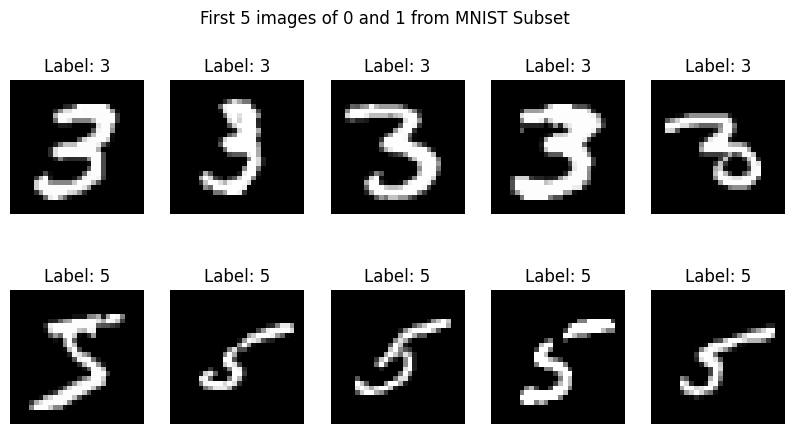

In [82]:
import matplotlib.pyplot as plt
# Visualizing the dataset
images_0 = X[y == 0]
images_1 = X[y == 1]
fig, axes = plt.subplots(2,5, figsize=(10,5))
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    #plotting digit 0
    axes[0,i].imshow(images_0[i].reshape(28,28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")
    #plotting digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")
  plt.suptitle("First 5 images of 0 and 1 from MNIST Subset")
  plt.show()



In [83]:
#initializing weights and bias
weights = np.zeros(X.shape[1]) # 784 wieghts one for each pixel
bias = 0
learning_rate = 0.1
epochs = 100

Question no-1: What does the weights array represent in this context?

The weights array represents how important each pixel is for recongnizing the digit.

Question no-2: Why are we initializing the weights to zero? What effect could this have on the training process?

we initialize weights to zero because it is a simple starting point where model begins with 0 prior knowledge.

# Implementation of Decision Function

In [84]:
def decision_function(X, weights, bias):

  predictions = np.dot(X, weights) + bias
  y_pred_all = []
  for value in predictions:
    if value > 0:
      y_pred_all.append(1)
    else:
      y_pred_all.append(0)
  return y_pred_all

## Training the Perceptron

In [85]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for i in range(epochs):
        for j in range(len(X)):
          z = np.dot(X[j], weights) + bias
          if z>= 0:
            y_pred = 1
          else:
            y_pred = 0
          if y_pred != y[j]:
            weights = weights + learning_rate * (y[j] - y_pred) * X[j]
            bias = bias + learning_rate * (y[j] - y_pred)
        if(i+1)%10==0:
          y_pred_all = decision_function(X, weights, bias)
          accuracy = np.mean(y_pred_all == y)
          print(f"Epoch {i+1} Accuracy: {accuracy}")

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

the main purpose of the output is that it calculates weighted sum of inputs by multiplying each pixel value with its weight adding all of them together and then adding the bias

Question no 6: What happens when the prediction is wrong? How are the weights and bias updated?

when the prediction is wrong it adjusts weight and bias multiplied by learning rate  to make the prediction correct.

Question - 7: Why is the final accuracy important, and what do you expect it to be?

the final accuract is very important as it tells how well the model has learned to recognize the pattern in the data. the expect hte output to be high accuracy as the data is easily seperable in 0 or 1.

## Training the perception algorithm

In [86]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print("The Final Accuracy is: ", accuracy)

Epoch 10 Accuracy: 0.961327982488143
Epoch 20 Accuracy: 0.9540313754104341
Epoch 30 Accuracy: 0.9730025538124772
Epoch 40 Accuracy: 0.9730025538124772
Epoch 50 Accuracy: 0.9518423932871215
Epoch 60 Accuracy: 0.951477562933236
Epoch 70 Accuracy: 0.9770156877052171
Epoch 80 Accuracy: 0.9861364465523531
Epoch 90 Accuracy: 0.9828529733673842
Epoch 100 Accuracy: 0.986866107260124
The Final Accuracy is:  0.986866107260124


# Visualizing Misclassified Images


Final Accuracy: 0.9869


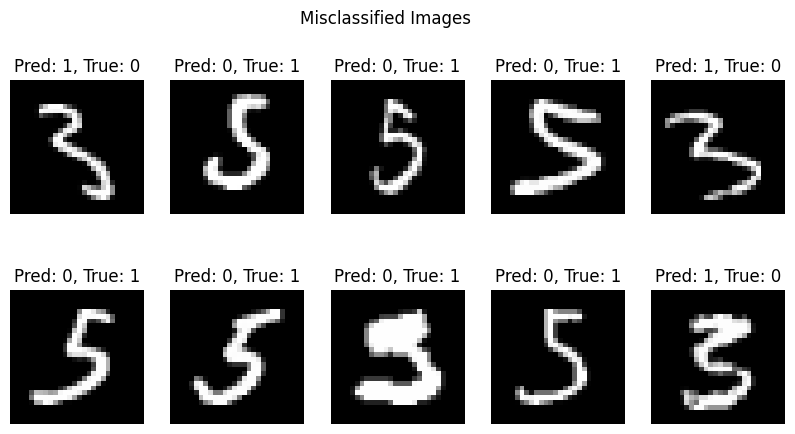

In [87]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Question - 8: What does misclassified idx store, and how is it used in this code?

misclassified idx stores the position number of all images that the model predicted incorrectly. after that it uses these numbers to pick those wrong images and show them in grid so we can see what digit model got wrong

Question - 9:How do you interpret the result if the output is ”All images were correctly classified!”?

If the output says all the images are correct classified then it means that model made zero mistakes and predicted every digit correctly.